**Install Packages**

In [52]:
!pip -q install kagglehub opencv-python-headless scikit-image openpyxl shap

**Imports**

In [53]:
import os, json, shutil, warnings, random, glob
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.preprocessing import StandardScaler, LabelEncoder

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

**Project Folder Names**

In [54]:
from google.colab import drive
drive.mount("/content/drive")

PROJECT_FOLDER = "BRSET XAI Project"

PROCESSED_SHARED_FOLDER = "processed shared"
PREPROCESSED_DATASET_FOLDER = "preprocessed dataset"

OUTPUTS_FOLDER = "outputs"
EDA_FIGURES_FOLDER_NAME = "eda figures"

IMAGE_MANIFEST_FILENAME = "brset image manifest.csv"
FEATURE_SELECTION_SCORES_FILENAME = "feature selection scores.csv"
SELECTED_TABULAR_FILENAME = "brset selected tabular.csv"
PREPROCESSING_METADATA_FILENAME = "preprocessing metadata.json"

TARGET_DISTRIBUTION_FIGURE_FILENAME = "target distribution by split.png"
MISSING_VALUE_SUMMARY_FIGURE_FILENAME = "missing value summary.png"
PATIENT_AGE_DISTRIBUTION_FIGURE_FILENAME = "patient age distribution.png"
FUNDUS_PREPROCESSING_PIPELINE_FIGURE_FILENAME = "fundus preprocessing pipeline.png"
FEATURE_CORRELATION_HEATMAP_FILENAME = "feature correlation heatmap.png"
FEATURE_SELECTION_RANKING_FIGURE_FILENAME = "feature selection ranking.png"

DATASET_SLUG = "tanzinabdul/fundus-patientwise-split"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Derived Paths**

In [55]:
PROJECT_ROOT = Path("/content/drive/MyDrive") / PROJECT_FOLDER

PROCESSED_SHARED_DIR = PROJECT_ROOT / PROCESSED_SHARED_FOLDER
PREPROCESSED_DATASET_DIR = PROCESSED_SHARED_DIR / PREPROCESSED_DATASET_FOLDER

OUTPUTS_DIR = PROJECT_ROOT / OUTPUTS_FOLDER
EDA_FIGURES_DIR = OUTPUTS_DIR / EDA_FIGURES_FOLDER_NAME

IMAGE_MANIFEST_PATH = PREPROCESSED_DATASET_DIR / IMAGE_MANIFEST_FILENAME
FEATURE_SELECTION_SCORES_PATH = PREPROCESSED_DATASET_DIR / FEATURE_SELECTION_SCORES_FILENAME
SELECTED_TABULAR_PATH = PREPROCESSED_DATASET_DIR / SELECTED_TABULAR_FILENAME
PREPROCESSING_METADATA_PATH = PREPROCESSED_DATASET_DIR / PREPROCESSING_METADATA_FILENAME

TARGET_DISTRIBUTION_FIGURE_PATH = EDA_FIGURES_DIR / TARGET_DISTRIBUTION_FIGURE_FILENAME
MISSING_VALUE_SUMMARY_FIGURE_PATH = EDA_FIGURES_DIR / MISSING_VALUE_SUMMARY_FIGURE_FILENAME
PATIENT_AGE_DISTRIBUTION_FIGURE_PATH = EDA_FIGURES_DIR / PATIENT_AGE_DISTRIBUTION_FIGURE_FILENAME
FUNDUS_PREPROCESSING_PIPELINE_FIGURE_PATH = EDA_FIGURES_DIR / FUNDUS_PREPROCESSING_PIPELINE_FIGURE_FILENAME
FEATURE_CORRELATION_HEATMAP_PATH = EDA_FIGURES_DIR / FEATURE_CORRELATION_HEATMAP_FILENAME
FEATURE_SELECTION_RANKING_FIGURE_PATH = EDA_FIGURES_DIR / FEATURE_SELECTION_RANKING_FIGURE_FILENAME

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PREPROCESSED_DATASET_DIR:", PREPROCESSED_DATASET_DIR)
print("EDA_FIGURES_DIR:", EDA_FIGURES_DIR)

PROJECT_ROOT: /content/drive/MyDrive/BRSET XAI Project
PREPROCESSED_DATASET_DIR: /content/drive/MyDrive/BRSET XAI Project/processed shared/preprocessed dataset
EDA_FIGURES_DIR: /content/drive/MyDrive/BRSET XAI Project/outputs/eda figures


**Kaggle Download**

In [56]:
import kagglehub
from pathlib import Path

dataset_path = kagglehub.dataset_download(DATASET_SLUG)

RAW_DIR = Path(dataset_path)

print("Dataset downloaded successfully.")
print("RAW_DIR:", RAW_DIR)

Using Colab cache for faster access to the 'fundus-patientwise-split' dataset.
Dataset downloaded successfully.
RAW_DIR: /kaggle/input/fundus-patientwise-split


**Discover Dataset Structure**

In [57]:
for root, dirs, files in os.walk(RAW_DIR):
    level = root.replace(str(RAW_DIR), "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{Path(root).name}/")
    for f in files[:5]:
        print(f"{indent}  {f}")

fundus-patientwise-split/
  dataset_split/
    val/
      val.csv
      images/
        img15800.jpg
        img03023.jpg
        img00485.jpg
        img04052.jpg
        img15491.jpg
    test/
      test.csv
      images/
        img08274.jpg
        img13038.jpg
        img06787.jpg
        img03754.jpg
        img09983.jpg
    train/
      train.csv
      images/
        img06411.jpg
        img12149.jpg
        img07546.jpg
        img09193.jpg
        img04861.jpg


**Find CSV Files**

In [58]:
csv_files = list(RAW_DIR.rglob("*.csv"))
csv_files

[PosixPath('/kaggle/input/fundus-patientwise-split/dataset_split/val/val.csv'),
 PosixPath('/kaggle/input/fundus-patientwise-split/dataset_split/test/test.csv'),
 PosixPath('/kaggle/input/fundus-patientwise-split/dataset_split/train/train.csv')]

In [59]:
for f in csv_files:
    print(f"\n--- {f.name} ---")
    temp = pd.read_csv(f)
    print(temp.shape)
    display(temp.head())
    print("\n")


--- val.csv ---
(1632, 34)


,image_id,patient_id,camera,patient_age,comorbidities,diabetes_time_y,insuline,patient_sex,exam_eye,diabetes,...,amd,vascular_occlusion,hypertensive_retinopathy,drusens,hemorrhage,retinal_detachment,myopic_fundus,increased_cup_disc,other,quality
0,img00017,9,Canon CR,13.0,diabetes1,2,yes,2,1,yes,...,0,0,0,0,0,0,0,0,0,Adequate
1,img00018,9,Canon CR,13.0,diabetes1,2,yes,2,2,yes,...,0,0,0,0,0,0,0,0,0,Adequate
2,img00035,18,Canon CR,22.0,diabetes1,23,yes,1,1,yes,...,0,0,0,0,0,0,0,0,0,Adequate
3,img00036,18,Canon CR,22.0,diabetes1,23,yes,1,2,yes,...,0,0,0,0,0,0,0,0,0,Adequate
4,img00053,27,Canon CR,24.0,diabetes1,8,yes,2,1,yes,...,0,0,0,0,0,0,0,0,0,Adequate





--- test.csv ---
(1619, 34)


,image_id,patient_id,camera,patient_age,comorbidities,diabetes_time_y,insuline,patient_sex,exam_eye,diabetes,...,amd,vascular_occlusion,hypertensive_retinopathy,drusens,hemorrhage,retinal_detachment,myopic_fundus,increased_cup_disc,other,quality
0,img00039,20,Canon CR,42.0,"diabetes1, hypertension",5,yes,1,1,yes,...,0,0,0,0,0,0,0,0,0,Adequate
1,img00040,20,Canon CR,42.0,"diabetes1, hypertension",5,yes,1,2,yes,...,0,0,0,0,0,0,0,0,0,Adequate
2,img00047,24,Canon CR,13.0,diabetes1,3,yes,2,1,yes,...,0,0,0,0,0,0,0,0,0,Adequate
3,img00048,24,Canon CR,13.0,diabetes1,3,yes,2,2,yes,...,0,0,0,0,0,0,0,0,0,Adequate
4,img00074,38,Canon CR,37.0,diabetes1,7,yes,1,1,yes,...,0,0,0,0,0,0,0,0,0,Adequate





--- train.csv ---
(13015, 34)


,image_id,patient_id,camera,patient_age,comorbidities,diabetes_time_y,insuline,patient_sex,exam_eye,diabetes,...,amd,vascular_occlusion,hypertensive_retinopathy,drusens,hemorrhage,retinal_detachment,myopic_fundus,increased_cup_disc,other,quality
0,img00001,1,Canon CR,48.0,diabetes1,12,yes,1,1,yes,...,0,0,0,0,0,0,0,1,0,Adequate
1,img00002,1,Canon CR,48.0,diabetes1,12,yes,1,2,yes,...,0,0,0,0,0,0,0,1,0,Adequate
2,img00003,2,Canon CR,18.0,diabetes1,7,yes,2,1,yes,...,0,0,0,0,0,0,0,0,0,Adequate
3,img00004,2,Canon CR,18.0,diabetes1,7,yes,2,2,yes,...,0,0,0,0,0,0,0,0,0,Adequate
4,img00005,3,Canon CR,22.0,diabetes1,11,yes,1,1,yes,...,0,0,0,0,0,0,0,0,0,Adequate


**Load Splits Dynamically**

In [60]:
def find_split_csv(split):
    candidates = [p for p in csv_files if split.lower() in p.name.lower()]
    return candidates[0]

train_csv = find_split_csv("train")
val_csv = find_split_csv("val")
test_csv = find_split_csv("test")

train_df = pd.read_csv(train_csv) if train_csv else None
val_df = pd.read_csv(val_csv) if val_csv else None
test_df = pd.read_csv(test_csv) if test_csv else None

print("train:", None if train_df is None else train_df.shape)
print("val:", None if val_df is None else val_df.shape)
print("test:", None if test_df is None else test_df.shape)

train: (13015, 34)
val: (1632, 34)
test: (1619, 34)


In [61]:
df = pd.concat(
    [
        train_df.assign(split="train"),
        val_df.assign(split="val"),
        test_df.assign(split="test")
    ],
    ignore_index=True
)

display(df.head())
print(df.shape)

,image_id,patient_id,camera,patient_age,comorbidities,diabetes_time_y,insuline,patient_sex,exam_eye,diabetes,...,vascular_occlusion,hypertensive_retinopathy,drusens,hemorrhage,retinal_detachment,myopic_fundus,increased_cup_disc,other,quality,split
0,img00001,1,Canon CR,48.0,diabetes1,12,yes,1,1,yes,...,0,0,0,0,0,0,1,0,Adequate,train
1,img00002,1,Canon CR,48.0,diabetes1,12,yes,1,2,yes,...,0,0,0,0,0,0,1,0,Adequate,train
2,img00003,2,Canon CR,18.0,diabetes1,7,yes,2,1,yes,...,0,0,0,0,0,0,0,0,Adequate,train
3,img00004,2,Canon CR,18.0,diabetes1,7,yes,2,2,yes,...,0,0,0,0,0,0,0,0,Adequate,train
4,img00005,3,Canon CR,22.0,diabetes1,11,yes,1,1,yes,...,0,0,0,0,0,0,0,0,Adequate,train


(16266, 35)


**Basic EDA**

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16266 entries, 0 to 16265
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   image_id                  16266 non-null  object 
 1   patient_id                16266 non-null  int64  
 2   camera                    16266 non-null  object 
 3   patient_age               10820 non-null  float64
 4   comorbidities             8029 non-null   object 
 5   diabetes_time_y           1910 non-null   object 
 6   insuline                  1714 non-null   object 
 7   patient_sex               16266 non-null  int64  
 8   exam_eye                  16266 non-null  int64  
 9   diabetes                  16266 non-null  object 
 10  nationality               16266 non-null  object 
 11  optic_disc                16266 non-null  object 
 12  vessels                   16266 non-null  int64  
 13  macula                    16266 non-null  int64  
 14  DR_SDR

In [63]:
df.head()

,image_id,patient_id,camera,patient_age,comorbidities,diabetes_time_y,insuline,patient_sex,exam_eye,diabetes,...,vascular_occlusion,hypertensive_retinopathy,drusens,hemorrhage,retinal_detachment,myopic_fundus,increased_cup_disc,other,quality,split
0,img00001,1,Canon CR,48.0,diabetes1,12,yes,1,1,yes,...,0,0,0,0,0,0,1,0,Adequate,train
1,img00002,1,Canon CR,48.0,diabetes1,12,yes,1,2,yes,...,0,0,0,0,0,0,1,0,Adequate,train
2,img00003,2,Canon CR,18.0,diabetes1,7,yes,2,1,yes,...,0,0,0,0,0,0,0,0,Adequate,train
3,img00004,2,Canon CR,18.0,diabetes1,7,yes,2,2,yes,...,0,0,0,0,0,0,0,0,Adequate,train
4,img00005,3,Canon CR,22.0,diabetes1,11,yes,1,1,yes,...,0,0,0,0,0,0,0,0,Adequate,train


In [64]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
image_id,16266,16266,img16264,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
patient_id,16266.0,NaN,NaN,NaN,4275.474302,2463.584452,1.0,2158.25,4270.0,6420.75,8524.0
camera,16266,2,Canon CR,10591,NaN,NaN,NaN,NaN,NaN,NaN,NaN
patient_age,10820.0,NaN,NaN,NaN,57.655453,18.261783,5.0,47.0,61.0,71.0,97.0
comorbidities,8029,213,0,2766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
diabetes_time_y,1910,55,10,252,NaN,NaN,NaN,NaN,NaN,NaN,NaN
insuline,1714,2,yes,893,NaN,NaN,NaN,NaN,NaN,NaN,NaN
patient_sex,16266.0,NaN,NaN,NaN,1.617976,0.485897,1.0,1.0,2.0,2.0,2.0
exam_eye,16266.0,NaN,NaN,NaN,1.498647,0.500014,1.0,1.0,1.0,2.0,2.0
diabetes,16266,2,No,13687,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Target Renaming and Distribution**

In [65]:
SOURCE_TARGET_COL = "DR_ICDR"

print("Selected target:", SOURCE_TARGET_COL)
display(df[SOURCE_TARGET_COL].value_counts(dropna=False).sort_index())

Selected target: DR_ICDR


,count
DR_ICDR,
0,15183
1,158
2,451
3,78
4,396


In [66]:
TARGET_COL = "target"
df[TARGET_COL] = df[SOURCE_TARGET_COL].astype(int)

**Target Distribution Plot**

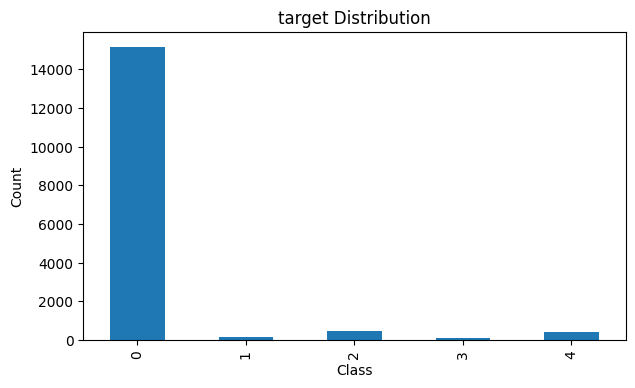

In [67]:
plt.figure(figsize=(7,4))
df[TARGET_COL].value_counts().sort_index().plot(kind="bar")
plt.title(f"{TARGET_COL} Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

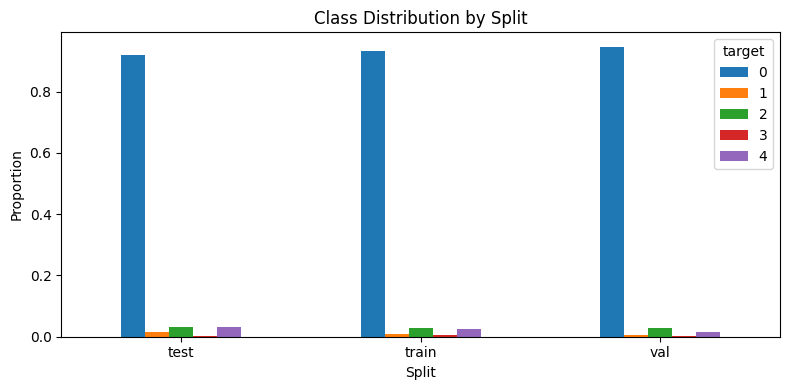

In [68]:
target_split_proportions = pd.crosstab(
    df["split"],
    df[TARGET_COL],
    normalize="index"
)

target_split_proportions.plot(kind="bar", figsize=(8, 4))
plt.title("Class Distribution by Split")
plt.xlabel("Split")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(TARGET_DISTRIBUTION_FIGURE_PATH, dpi=300, bbox_inches="tight")
plt.show()

In [69]:
target_split_counts = pd.crosstab(df["split"], df[TARGET_COL])
target_split_proportions = pd.crosstab(df["split"], df[TARGET_COL], normalize="index")

display(target_split_counts)

print("\n")

display(target_split_proportions.round(4))

target,0,1,2,3,4
split,,,,,
test,1488,23,50,6,52
train,12151,124,357,66,317
val,1544,11,44,6,27


target,0,1,2,3,4
split,,,,,
test,0.9191,0.0142,0.0309,0.0037,0.0321
train,0.9336,0.0095,0.0274,0.0051,0.0244
val,0.9461,0.0067,0.0270,0.0037,0.0165


**Missing Value Summary**

In [70]:
missing_summary = (
    pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_ratio": df.isna().mean()
    })
    .sort_values("missing_count", ascending=False)
)

display(missing_summary[missing_summary["missing_count"] > 0])

,missing_count,missing_ratio
insuline,14552,0.894627
diabetes_time_y,14356,0.882577
comorbidities,8237,0.506394
patient_age,5446,0.334809


**Missing Values Visualization**

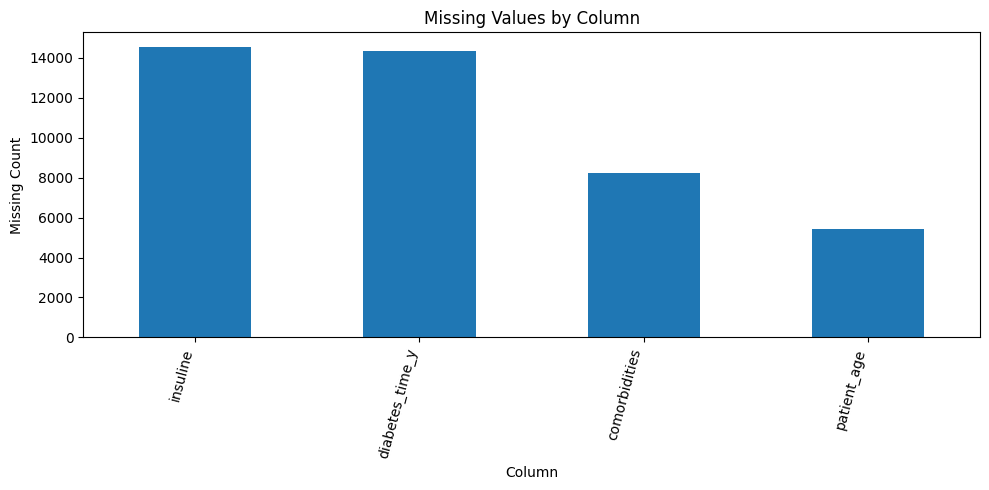

In [71]:
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values = missing_values[missing_values > 0]

plt.figure(figsize=(10, 5))
missing_values.plot(kind="bar")
plt.title("Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Missing Count")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.savefig(MISSING_VALUE_SUMMARY_FIGURE_PATH, dpi=300, bbox_inches="tight")
plt.show()

**Duplicate and Column Integrity Check**

In [72]:
print("Duplicate rows:", df.duplicated().sum())

if "image_id" in df.columns:
    print("Duplicate image_id rows:", df["image_id"].duplicated().sum())

if "patient_id" in df.columns and "exam_eye" in df.columns:
    print(
        "Duplicate patient-eye rows:",
        df.duplicated(subset=["patient_id", "exam_eye"]).sum()
    )

Duplicate rows: 0
Duplicate image_id rows: 0
Duplicate patient-eye rows: 130


**Patient Split Leakage Check**

In [73]:
patient_split_counts = (
    df.groupby("patient_id")["split"]
    .nunique()
    .sort_values(ascending=False)
)

leaked_patients = patient_split_counts[patient_split_counts > 1]

print("Patients appearing in more than one split:", len(leaked_patients))

if len(leaked_patients) > 0:
    display(leaked_patients.head(20))
else:
    print("No patient-level split leakage detected.")

Patients appearing in more than one split: 0
No patient-level split leakage detected.


**Duplicate Patient Eye Investigation**

In [74]:
DUPLICATE_PATIENT_EYE_COLUMNS = ["patient_id", "exam_eye"]

duplicate_patient_eye_mask = df.duplicated(
    subset=DUPLICATE_PATIENT_EYE_COLUMNS,
    keep=False
)

duplicate_patient_eye_df = (
    df.loc[duplicate_patient_eye_mask]
    .sort_values(DUPLICATE_PATIENT_EYE_COLUMNS + ["image_id"])
)

n_duplicate_patient_eye_rows = duplicate_patient_eye_df.shape[0]

n_duplicate_patient_eye_groups = (duplicate_patient_eye_df.groupby(DUPLICATE_PATIENT_EYE_COLUMNS).ngroups)

print("Rows involved in duplicate patient-eye records:", n_duplicate_patient_eye_rows)
print("Number of duplicated patient-eye groups:", n_duplicate_patient_eye_groups)

Rows involved in duplicate patient-eye records: 258
Number of duplicated patient-eye groups: 128


**Duplicate Patient-Eye Consistency Check**

In [75]:
duplicate_group_summary = (
    duplicate_patient_eye_df
    .groupby(DUPLICATE_PATIENT_EYE_COLUMNS)
    .agg(
        n_rows=("image_id", "count"),
        n_targets=(TARGET_COL, "nunique"),
        target_values=(TARGET_COL, lambda x: sorted(x.unique().tolist()))
    )
    .reset_index()
)

In [76]:
print("\nDuplicate patient-eye group size distribution:")
display(
    duplicate_group_summary["n_rows"]
    .value_counts()
    .sort_index()
    .rename("group_count")
    .to_frame()
)

print("\n")

print("\nPatient-eye groups with 3 records:")
display(
    duplicate_group_summary[
        duplicate_group_summary["n_rows"] == 3
    ].sort_values(DUPLICATE_PATIENT_EYE_COLUMNS)
)


Duplicate patient-eye group size distribution:


,group_count
n_rows,
2,126
3,2





Patient-eye groups with 3 records:


,patient_id,exam_eye,n_rows,n_targets,target_values
94,5661,2,3,1,[0]
115,7814,1,3,1,[0]


In [77]:
target_conflicts = duplicate_group_summary[duplicate_group_summary["n_targets"] > 1]

print("Duplicate patient-eye groups with target conflicts:", len(target_conflicts))

if len(target_conflicts) > 0:
    print("\nTarget-conflicting patient-eye groups:")
    display(target_conflicts)

Duplicate patient-eye groups with target conflicts: 4

Target-conflicting patient-eye groups:


,patient_id,exam_eye,n_rows,n_targets,target_values
33,1476,1,2,2,"[0, 3]"
34,1476,2,2,2,"[0, 4]"
110,7429,1,2,2,"[1, 2]"
118,7941,1,2,2,"[0, 2]"


**Inspect Target-Conflicting Patient-Eye Records**

In [78]:
target_conflict_keys = target_conflicts[DUPLICATE_PATIENT_EYE_COLUMNS].drop_duplicates()

target_conflict_rows = (
    duplicate_patient_eye_df
    .merge(
        target_conflict_keys,
        on=DUPLICATE_PATIENT_EYE_COLUMNS,
        how="inner"
    )
    .sort_values(DUPLICATE_PATIENT_EYE_COLUMNS + [TARGET_COL, "image_id"])
)

display_cols = [
    "image_id",
    "patient_id",
    "exam_eye",
    "split",
    TARGET_COL,
    "patient_age",
    "diabetes",
    "macula",
    "macular_edema",
    "DR_SDRG"
]

display_cols = [
    col for col in display_cols
    if col in target_conflict_rows.columns
]

print("Rows involved in target-conflicting patient-eye groups:", len(target_conflict_rows))
display(target_conflict_rows[display_cols])

Rows involved in target-conflicting patient-eye groups: 8


,image_id,patient_id,exam_eye,split,target,patient_age,diabetes,macula,macular_edema,DR_SDRG
1,img02796,1476,1,train,0,NaN,No,2,0,0
0,img02794,1476,1,train,3,NaN,No,2,1,3
2,img02793,1476,2,train,0,NaN,No,2,0,0
3,img02795,1476,2,train,4,NaN,No,2,1,4
5,img14138,7429,1,train,1,72.0,yes,1,0,1
4,img14137,7429,1,train,2,72.0,yes,2,0,3
6,img15146,7941,1,train,0,68.0,yes,1,0,0
7,img15147,7941,1,train,2,68.0,yes,1,1,1


**Flag Target-Conflicting Patient-Eye Records**

In [79]:
df["target_conflict_patient_eye"] = 0

conflict_image_ids = target_conflict_rows["image_id"].drop_duplicates().tolist()

df.loc[
    df["image_id"].isin(conflict_image_ids),
    "target_conflict_patient_eye"
] = 1

print("Rows flagged as target-conflicting patient-eye records:")
print(df["target_conflict_patient_eye"].sum())

flagged_conflict_rows = (
    df[df["target_conflict_patient_eye"] == 1]
    .sort_values(DUPLICATE_PATIENT_EYE_COLUMNS + [TARGET_COL, "image_id"])
)

flagged_display_cols = [
    "image_id",
    "patient_id",
    "exam_eye",
    "split",
    TARGET_COL,
    "target_conflict_patient_eye"
]

display(flagged_conflict_rows[flagged_display_cols])

assert df["target_conflict_patient_eye"].sum() == len(conflict_image_ids)

Rows flagged as target-conflicting patient-eye records:
8


,image_id,patient_id,exam_eye,split,target,target_conflict_patient_eye
2193,img02796,1476,1,train,0,1
2191,img02794,1476,1,train,3,1
2190,img02793,1476,2,train,0,1
2192,img02795,1476,2,train,4,1
11322,img14138,7429,1,train,1,1
11321,img14137,7429,1,train,2,1
12123,img15146,7941,1,train,0,1
12124,img15147,7941,1,train,2,1


**Column Role Definition**

In [80]:
ID_COLUMNS = [
    "image_id",
    "patient_id"
]

CONTROL_COLUMNS = [
    "split",
    "exam_eye"
]

IMAGE_METADATA_COLUMNS = [
    "image_path",
    "processed_image_path"
]

TARGET_COLUMNS = [
    "diabetic_retinopathy",
    "DR_ICDR",
    "DR_SDRG",
    "dr_icdr",
    "dr_sdrg"
]

HIGH_MISSING_COLUMNS = [
    "insuline",
    "diabetes_time_y",
    "comorbidities"
]

LOW_INFORMATION_COLUMNS = [
    "nationality"
]

ACQUISITION_OR_QUALITY_COLUMNS = [
    "camera",
    "focus",
    "Illuminaton",
    "image_field",
    "artifacts",
    "quality"
]

AUDIT_COLUMNS = [
    "target_conflict_patient_eye"
]

OTHER_NON_CORE_COLUMNS = [
    "other"
]

**Candidate Tabular Feature Columns**

In [81]:
excluded_from_features = (
    ID_COLUMNS
    + CONTROL_COLUMNS
    + IMAGE_METADATA_COLUMNS
    + TARGET_COLUMNS
    + HIGH_MISSING_COLUMNS
    + LOW_INFORMATION_COLUMNS
    + ACQUISITION_OR_QUALITY_COLUMNS
    + OTHER_NON_CORE_COLUMNS
    + AUDIT_COLUMNS
)

existing_excluded_columns = [
    col for col in excluded_from_features
]

candidate_feature_columns = [
    col for col in df.columns
    if col not in existing_excluded_columns
    and col != TARGET_COL
]

print("Target column:", TARGET_COL)

print("\nNumber of candidate tabular features:", len(candidate_feature_columns))

print("\nCandidate tabular feature columns:")
for col in candidate_feature_columns:
    print("-", col)

print("\nNumber of excluded columns:", len(existing_excluded_columns))

print("\nExcluded columns:")
for col in existing_excluded_columns:
    print("-", col)

Target column: target

Number of candidate tabular features: 17

Candidate tabular feature columns:
- patient_age
- patient_sex
- diabetes
- optic_disc
- vessels
- macula
- macular_edema
- scar
- nevus
- amd
- vascular_occlusion
- hypertensive_retinopathy
- drusens
- hemorrhage
- retinal_detachment
- myopic_fundus
- increased_cup_disc

Number of excluded columns: 23

Excluded columns:
- image_id
- patient_id
- split
- exam_eye
- image_path
- processed_image_path
- diabetic_retinopathy
- DR_ICDR
- DR_SDRG
- dr_icdr
- dr_sdrg
- insuline
- diabetes_time_y
- comorbidities
- nationality
- camera
- focus
- Illuminaton
- image_field
- artifacts
- quality
- other
- target_conflict_patient_eye


**Candidate Feature Type Audit**

In [82]:
candidate_feature_audit_rows = []

for col in candidate_feature_columns:
    values = df[col].dropna().unique().tolist()
    sample_values = values[:10]

    candidate_feature_audit_rows.append({
        "column": col,
        "dtype": str(df[col].dtype),
        "missing_count": df[col].isna().sum(),
        "missing_ratio": df[col].isna().mean(),
        "unique_count": df[col].nunique(dropna=True),
        "sample_values": sample_values
    })

candidate_feature_audit = pd.DataFrame(candidate_feature_audit_rows)

display(candidate_feature_audit)

,column,dtype,missing_count,missing_ratio,unique_count,sample_values
0,patient_age,float64,5446,0.334809,92,"[48.0, 18.0, 22.0, 23.0, 14.0, 20.0, 28.0, 37...."
1,patient_sex,int64,0,0.000000,2,"[1, 2]"
2,diabetes,object,0,0.000000,2,"[yes, No]"
3,optic_disc,object,0,0.000000,5,"[1, 2, 1, 2, bv]"
4,vessels,int64,0,0.000000,2,"[1, 2]"
5,macula,int64,0,0.000000,2,"[1, 2]"
6,macular_edema,int64,0,0.000000,2,"[0, 1]"
7,scar,int64,0,0.000000,2,"[0, 1]"
8,nevus,int64,0,0.000000,2,"[0, 1]"
9,amd,int64,0,0.000000,2,"[0, 1]"


**Continuous Feature Outlier Audit**

Numeric candidate features:
['patient_age', 'patient_sex', 'vessels', 'macula', 'macular_edema', 'scar', 'nevus', 'amd', 'vascular_occlusion', 'hypertensive_retinopathy', 'drusens', 'hemorrhage', 'retinal_detachment', 'myopic_fundus', 'increased_cup_disc']

Continuous candidate features:
['patient_age']




,count,mean,std,min,25%,50%,75%,max
patient_age,10820.0,57.655453,18.261783,5.0,47.0,61.0,71.0,97.0



Feature: patient_age
Q1: 47.0
Q3: 71.0
IQR: 24.0
IQR lower bound: 11.0
IQR upper bound: 107.0
IQR outlier count: 61




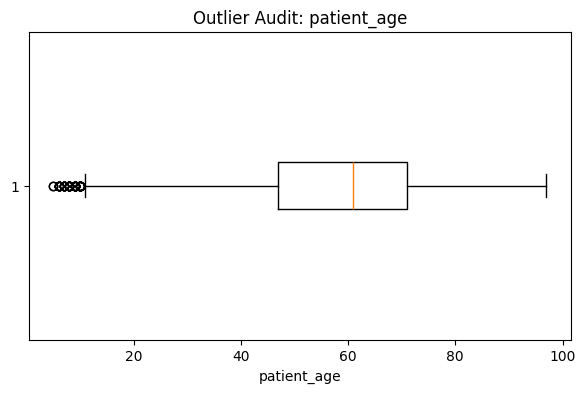

In [83]:
numeric_candidate_features = [
    col for col in candidate_feature_columns
    if pd.api.types.is_numeric_dtype(df[col])
]

continuous_candidate_features = [
    col for col in numeric_candidate_features
    if df[col].nunique(dropna=True) > 10
]

print("Numeric candidate features:")
print(numeric_candidate_features)

print("\nContinuous candidate features:")
print(continuous_candidate_features)

print("\n")

display(df[continuous_candidate_features].describe().T)

for col in continuous_candidate_features:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower_iqr = q1 - 1.5 * iqr
    upper_iqr = q3 + 1.5 * iqr

    iqr_outlier_mask = ((df[col] < lower_iqr) | (df[col] > upper_iqr))

    print(f"\nFeature: {col}")
    print("Q1:", q1)
    print("Q3:", q3)
    print("IQR:", iqr)
    print("IQR lower bound:", lower_iqr)
    print("IQR upper bound:", upper_iqr)
    print("IQR outlier count:", iqr_outlier_mask.sum())

    print("\n")

    plt.figure(figsize=(7, 4))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Outlier Audit: {col}")
    plt.xlabel(col)
    plt.show()

**No Flags will be applied to patient age outliers as it is clinically possible to have diabetic retinopathy at ages below 11 and above 107**

**Apply Row-Level Cleaning**

In [84]:
original_row_count = len(df)

df = df[df["target_conflict_patient_eye"] == 0].copy()

print("Original rows:", original_row_count)
print("Clean rows:", len(df))
print("Removed rows:", original_row_count - len(df))

print("\nRemoved target-conflicting patient-eye rows:")
print(original_row_count - len(df))

Original rows: 16266
Clean rows: 16258
Removed rows: 8

Removed target-conflicting patient-eye rows:
8


**Image Path Discovery and Validation**

In [85]:
IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png"]

image_files = [
    path
    for path in RAW_DIR.rglob("*")
    if path.suffix.lower() in IMAGE_EXTENSIONS
]

print("Total image files found:", len(image_files))

image_path_map = {
    path.stem: str(path)
    for path in image_files
}

df["image_path"] = df["image_id"].map(image_path_map)
df["processed_image_path"] = df["image_path"]

Total image files found: 16266


**Image Readability and Size Audit**

In [86]:
image_audit_rows = []

for image_path in tqdm(df["image_path"].dropna().tolist()):
    image = cv2.imread(str(image_path))

    if image is None:
        image_audit_rows.append({
            "image_path": image_path,
            "readable": 0,
            "height": np.nan,
            "width": np.nan,
            "channels": np.nan
        })
    else:
        height, width = image.shape[:2]
        channels = image.shape[2] if len(image.shape) == 3 else 1

        image_audit_rows.append({
            "image_path": image_path,
            "readable": 1,
            "height": height,
            "width": width,
            "channels": channels
        })

image_audit_df = pd.DataFrame(image_audit_rows)

print("Unreadable images:", (image_audit_df["readable"] == 0).sum())
print("Readable image ratio:", image_audit_df["readable"].mean())

display(image_audit_df[["height", "width", "channels"]].describe().T)

  0%|          | 0/16258 [00:00<?, ?it/s]

Unreadable images: 0
Readable image ratio: 1.0


,count,mean,std,min,25%,50%,75%,max
height,16258.0,2044.027064,251.809779,874.0,1880.0,2056.0,2304.0,2304.0
width,16258.0,2634.344384,355.195813,951.0,2420.0,2672.0,2984.0,2984.0
channels,16258.0,3.000000,0.000000,3.0,3.0,3.0,3.0,3.0


**Shared Fundus Preprocessing Visualization**

In [87]:
import sys

SRC_DIR = PROJECT_ROOT / "src"
sys.path.append(str(SRC_DIR))

from funduspreprocessing import preprocess_fundus

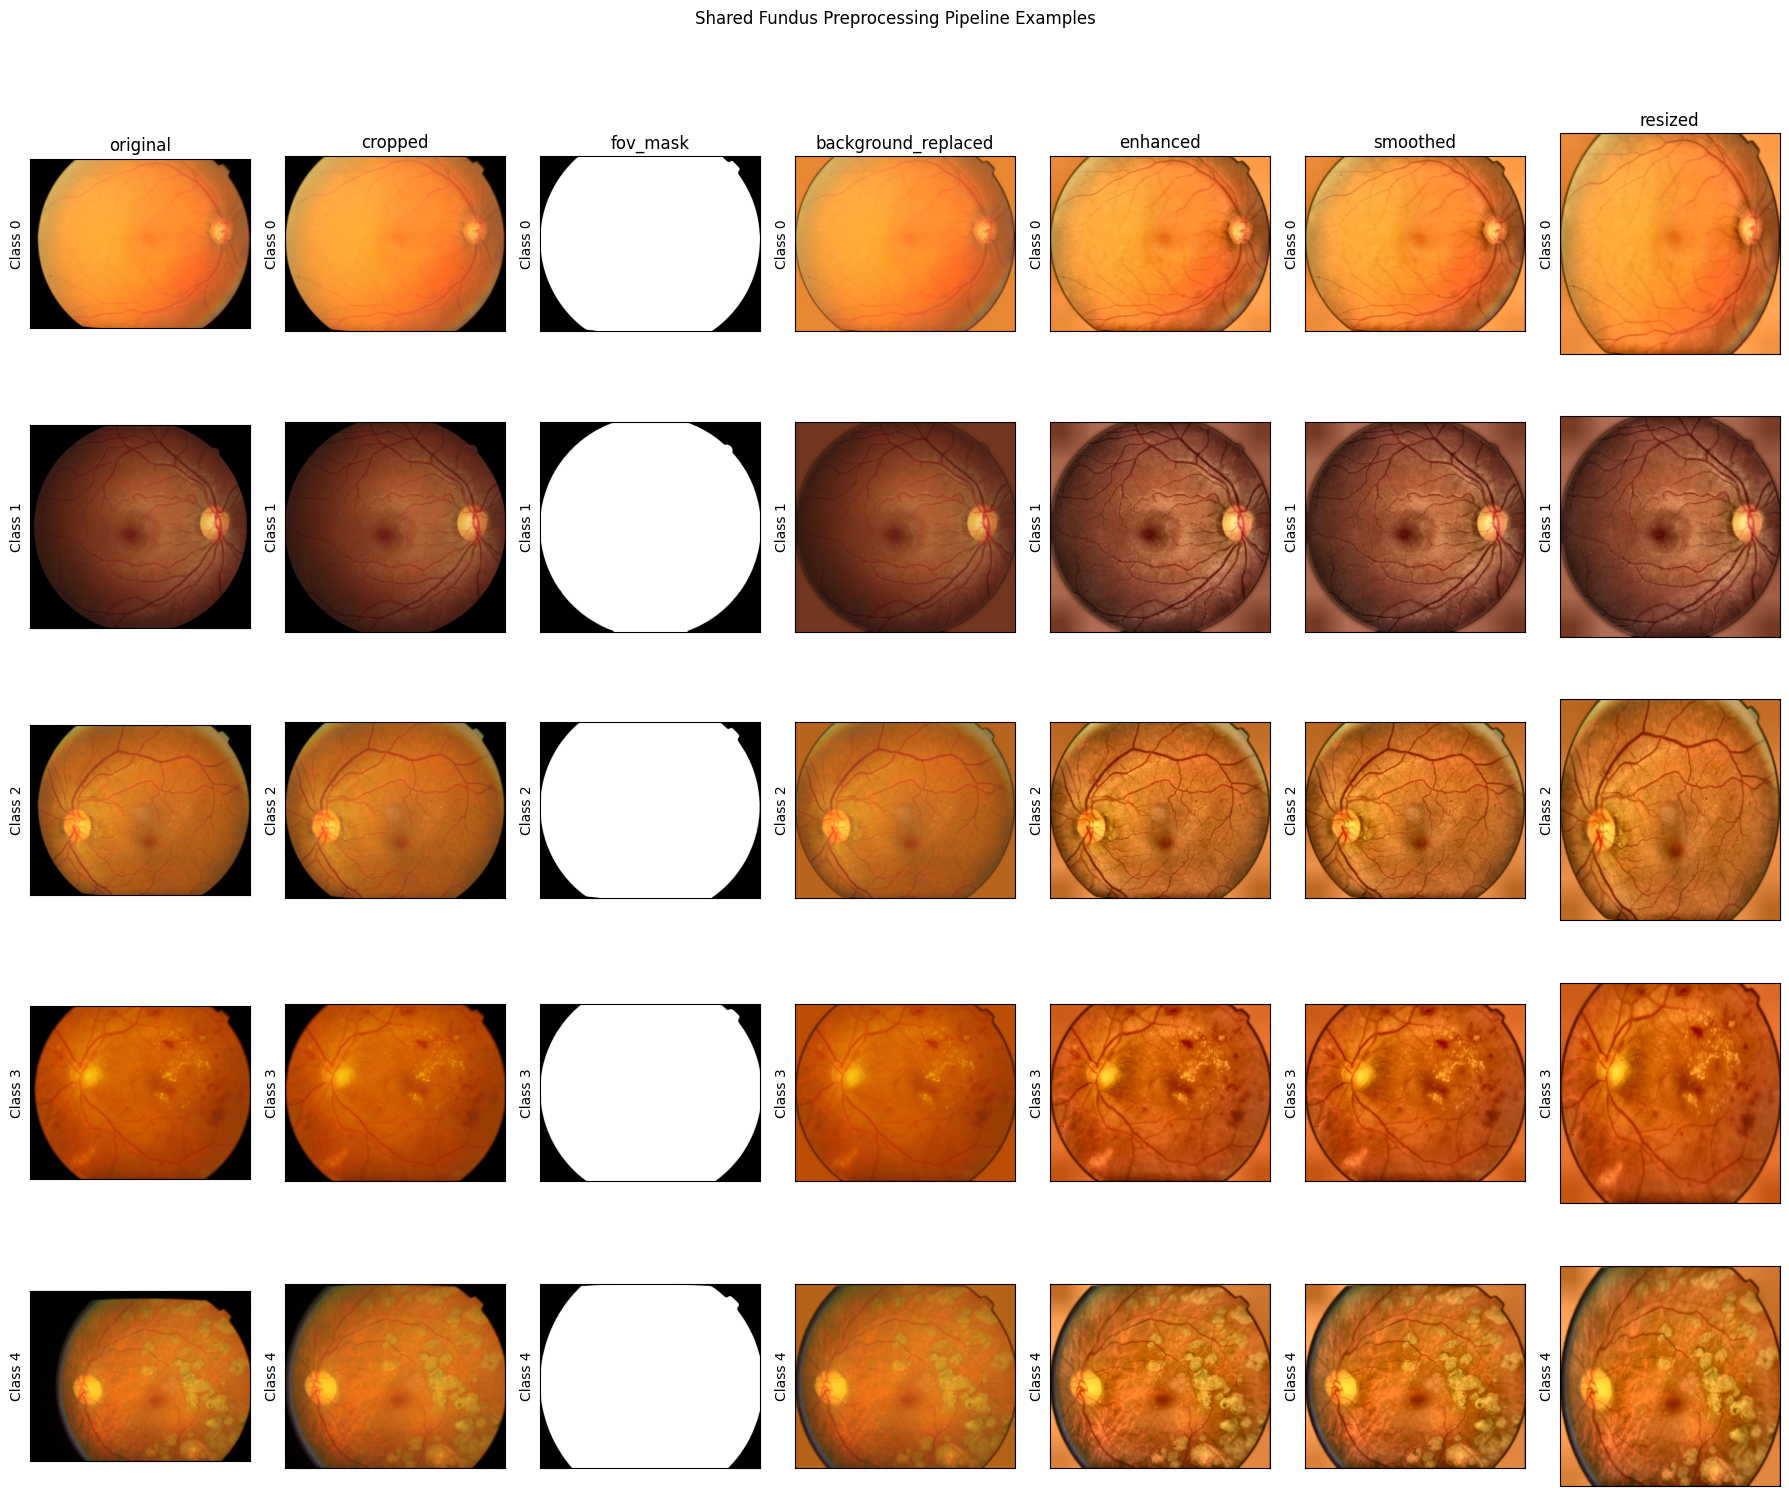

In [88]:
sample_rows = (
    df
    .groupby(TARGET_COL, group_keys=False)
    .apply(lambda x: x.sample(1, random_state=SEED))
    .reset_index(drop=True)
)

step_names = [
    "original",
    "cropped",
    "fov_mask",
    "background_replaced",
    "enhanced",
    "smoothed",
    "resized"
]

fig, axes = plt.subplots(
    nrows=len(sample_rows),
    ncols=len(step_names),
    figsize=(18, 3 * len(sample_rows))
)

for row_index, (_, row) in enumerate(sample_rows.iterrows()):
    steps = preprocess_fundus(
        row["processed_image_path"],
        img_size=224,
        return_steps=True
    )

    for step_index, step_name in enumerate(step_names):
        ax = axes[row_index, step_index]

        if step_name == "fov_mask":
            ax.imshow(steps[step_name], cmap="gray")
        else:
            ax.imshow(steps[step_name])

        if row_index == 0:
            ax.set_title(step_name)

        ax.set_ylabel(f"Class {row[TARGET_COL]}")
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle("Shared Fundus Preprocessing Pipeline Examples", y=1.02)
plt.tight_layout()
plt.savefig(FUNDUS_PREPROCESSING_PIPELINE_FIGURE_PATH, dpi=300, bbox_inches="tight")
plt.show()

**Save Image Training Manifest**

In [89]:
image_manifest = df[["processed_image_path", TARGET_COL, "split"]].copy()

image_manifest.to_csv(IMAGE_MANIFEST_PATH, index=False)

**Candidate Tabular Feature Audit After Cleaning**

In [90]:
clean_candidate_feature_audit_rows = []

for col in candidate_feature_columns:
    values = df[col].dropna().unique().tolist()
    sample_values = values[:10]

    clean_candidate_feature_audit_rows.append({
        "column": col,
        "dtype": str(df[col].dtype),
        "missing_count": df[col].isna().sum(),
        "missing_ratio": df[col].isna().mean(),
        "unique_count": df[col].nunique(dropna=True),
        "sample_values": sample_values
    })

clean_candidate_feature_audit = pd.DataFrame(clean_candidate_feature_audit_rows)

display(clean_candidate_feature_audit)

,column,dtype,missing_count,missing_ratio,unique_count,sample_values
0,patient_age,float64,5442,0.334728,92,"[48.0, 18.0, 22.0, 23.0, 14.0, 20.0, 28.0, 37...."
1,patient_sex,int64,0,0.000000,2,"[1, 2]"
2,diabetes,object,0,0.000000,2,"[yes, No]"
3,optic_disc,object,0,0.000000,5,"[1, 2, 1, 2, bv]"
4,vessels,int64,0,0.000000,2,"[1, 2]"
5,macula,int64,0,0.000000,2,"[1, 2]"
6,macular_edema,int64,0,0.000000,2,"[0, 1]"
7,scar,int64,0,0.000000,2,"[0, 1]"
8,nevus,int64,0,0.000000,2,"[0, 1]"
9,amd,int64,0,0.000000,2,"[0, 1]"


**Infer Tabular Feature Types**

In [91]:
candidate_tabular_df = df[candidate_feature_columns]

numeric_feature_columns = candidate_tabular_df.select_dtypes(include=np.number).columns.tolist()

categorical_feature_columns = candidate_tabular_df.select_dtypes(exclude=np.number).columns.tolist()

continuous_numeric_features = [
    col for col in numeric_feature_columns
    if candidate_tabular_df[col].nunique(dropna=True) > 10
]

discrete_numeric_features = [
    col for col in numeric_feature_columns
    if col not in continuous_numeric_features
]

print("Numeric feature columns:")
print(numeric_feature_columns)

print("\nContinuous numeric features:")
print(continuous_numeric_features)

print("\nDiscrete numeric features:")
print(discrete_numeric_features)

print("\nCategorical feature columns:")
print(categorical_feature_columns)

Numeric feature columns:
['patient_age', 'patient_sex', 'vessels', 'macula', 'macular_edema', 'scar', 'nevus', 'amd', 'vascular_occlusion', 'hypertensive_retinopathy', 'drusens', 'hemorrhage', 'retinal_detachment', 'myopic_fundus', 'increased_cup_disc']

Continuous numeric features:
['patient_age']

Discrete numeric features:
['patient_sex', 'vessels', 'macula', 'macular_edema', 'scar', 'nevus', 'amd', 'vascular_occlusion', 'hypertensive_retinopathy', 'drusens', 'hemorrhage', 'retinal_detachment', 'myopic_fundus', 'increased_cup_disc']

Categorical feature columns:
['diabetes', 'optic_disc']


**Continuous Numeric Feature Distribution**

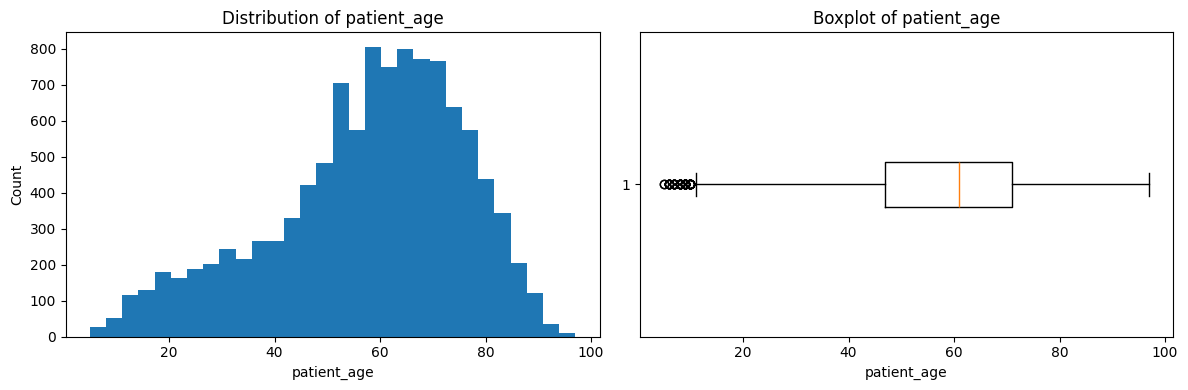

In [92]:
for col in continuous_numeric_features:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(df[col].dropna(), bins=30)
    axes[0].set_title(f"Distribution of {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Count")

    axes[1].boxplot(df[col].dropna(), vert=False)
    axes[1].set_title(f"Boxplot of {col}")
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.savefig(PATIENT_AGE_DISTRIBUTION_FIGURE_PATH, dpi=300, bbox_inches="tight")
    plt.show()

**Discrete Numeric Feature Distributions**

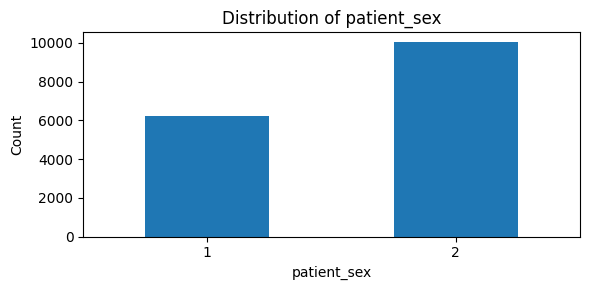

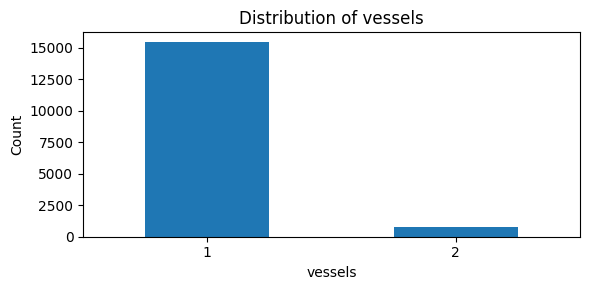

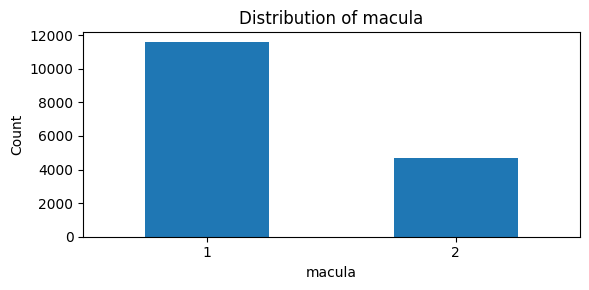

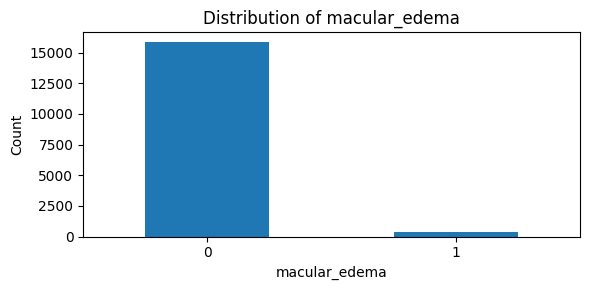

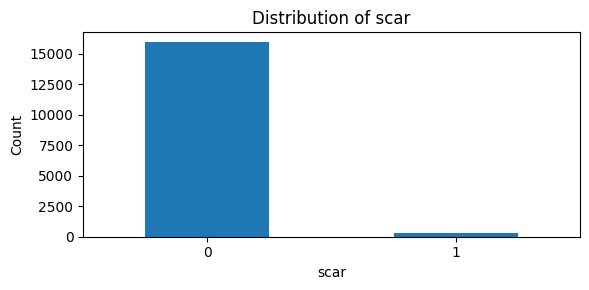

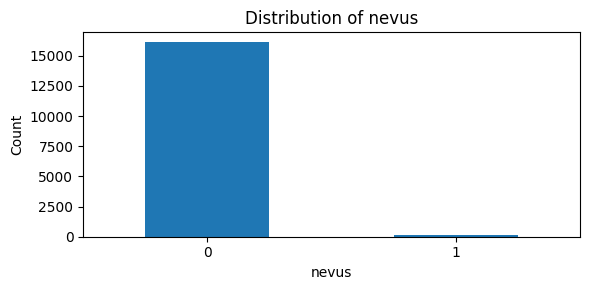

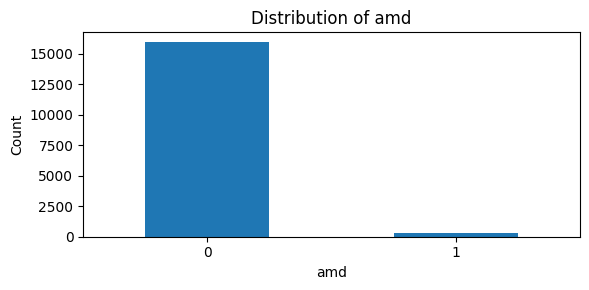

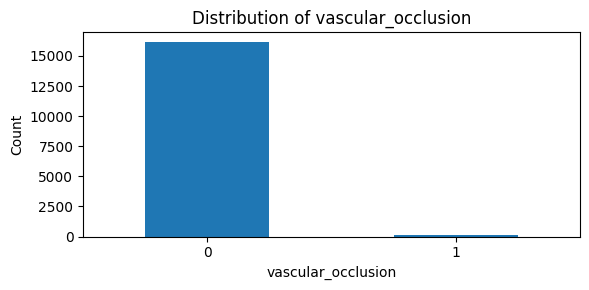

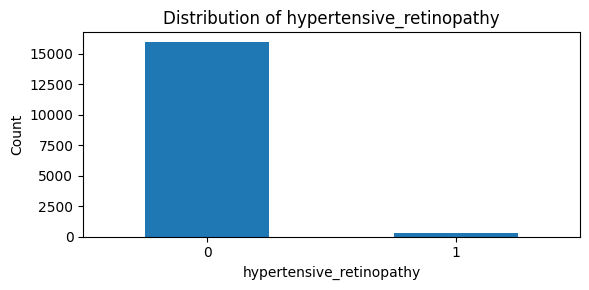

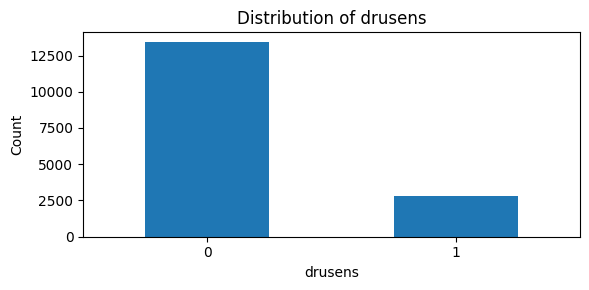

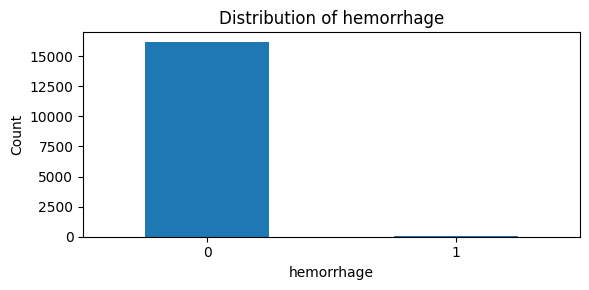

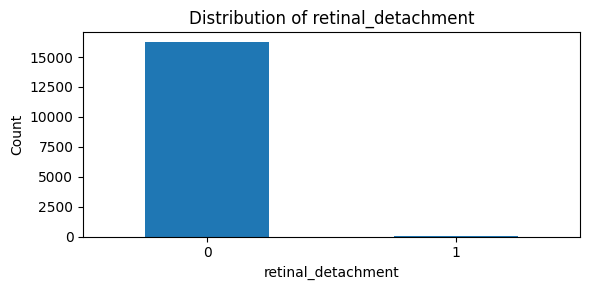

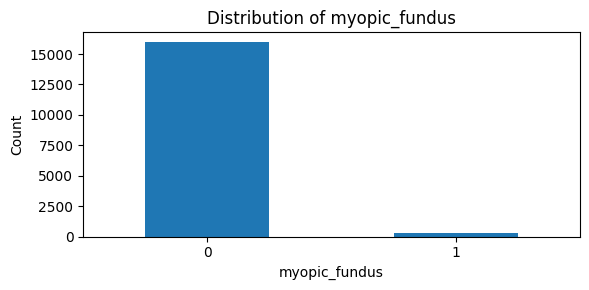

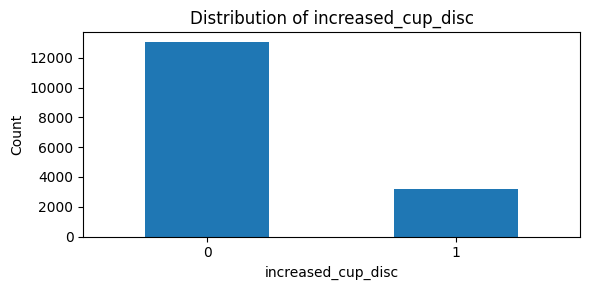

In [93]:
for col in discrete_numeric_features:
    plt.figure(figsize=(6, 3))
    df[col].value_counts(dropna=False).sort_index().plot(kind="bar")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
    print("\n")

**Categorical Feature Value Audit and Distribution**


diabetes


,count
diabetes,
No,13683
yes,2575


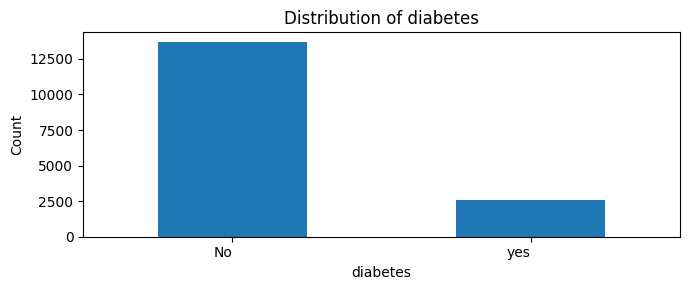




optic_disc


,count
optic_disc,
1,12978
2,3279
bv,1


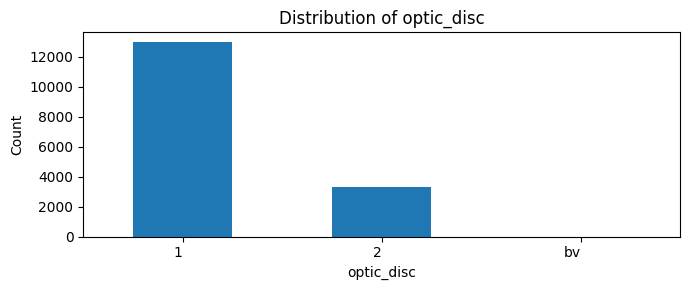

In [94]:
for col in categorical_feature_columns:
    print(f"\n{col}")
    value_counts = (
        df[col]
        .astype(str)
        .value_counts(dropna=False)
        .to_frame("count")
    )

    display(value_counts)

    plt.figure(figsize=(7, 3))
    value_counts["count"].plot(kind="bar")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=0, ha="right")
    plt.tight_layout()
    plt.show()

    print("\n")

**Tabular Data Preprocessing**

In [95]:
train_mask = df["split"] == "train"

df["patient_age_missing"] = df["patient_age"].isna().astype(int)

patient_age_median = df.loc[train_mask, "patient_age"].median()
df["patient_age"] = df["patient_age"].fillna(patient_age_median)

df["patient_age_for_cohort"] = df["patient_age"]
df["patient_sex_for_cohort"] = df["patient_sex"]
df["diabetes_for_cohort"] = df["diabetes"].astype(str)

age_scaler = StandardScaler()

df.loc[train_mask, ["patient_age"]] = age_scaler.fit_transform(
    df.loc[train_mask, ["patient_age"]]
)

df.loc[~train_mask, ["patient_age"]] = age_scaler.transform(
    df.loc[~train_mask, ["patient_age"]]
)

categorical_encoder_mappings = {}

for col in categorical_feature_columns:
    encoder = LabelEncoder()
    train_values = df.loc[train_mask, col].astype(str)

    encoder.fit(train_values)

    mapping = {
        class_name: int(class_index)
        for class_index, class_name in enumerate(encoder.classes_)
    }

    df[col] = (
        df[col]
        .astype(str)
        .map(mapping)
        .fillna(-1)
        .astype(int)
    )

    categorical_encoder_mappings[col] = mapping

processed_feature_columns = candidate_feature_columns.copy()
processed_feature_columns.append("patient_age_missing")

cohort_columns = [
    "patient_age_for_cohort",
    "patient_sex_for_cohort",
    "diabetes_for_cohort"
]

display(
    df[
        ["processed_image_path", "split", TARGET_COL]
        + processed_feature_columns
        + cohort_columns
    ].head()
)

,processed_image_path,split,target,patient_age,patient_sex,diabetes,optic_disc,vessels,macula,macular_edema,...,hypertensive_retinopathy,drusens,hemorrhage,retinal_detachment,myopic_fundus,increased_cup_disc,patient_age_missing,patient_age_for_cohort,patient_sex_for_cohort,diabetes_for_cohort
0,/kaggle/input/fundus-patientwise-split/dataset...,train,0,-0.730719,1,1,0,1,1,0,...,0,0,0,0,0,1,0,48.0,1,yes
1,/kaggle/input/fundus-patientwise-split/dataset...,train,0,-0.730719,1,1,1,1,1,0,...,0,0,0,0,0,1,0,48.0,1,yes
2,/kaggle/input/fundus-patientwise-split/dataset...,train,0,-2.734722,2,1,0,1,1,0,...,0,0,0,0,0,0,0,18.0,2,yes
3,/kaggle/input/fundus-patientwise-split/dataset...,train,0,-2.734722,2,1,0,1,1,0,...,0,0,0,0,0,0,0,18.0,2,yes
4,/kaggle/input/fundus-patientwise-split/dataset...,train,0,-2.467522,1,1,1,1,1,0,...,0,0,0,0,0,0,0,22.0,1,yes


In [96]:
df.columns

Index(['image_id', 'patient_id', 'camera', 'patient_age', 'comorbidities',
       'diabetes_time_y', 'insuline', 'patient_sex', 'exam_eye', 'diabetes',
       'nationality', 'optic_disc', 'vessels', 'macula', 'DR_SDRG', 'DR_ICDR',
       'focus', 'Illuminaton', 'image_field', 'artifacts',
       'diabetic_retinopathy', 'macular_edema', 'scar', 'nevus', 'amd',
       'vascular_occlusion', 'hypertensive_retinopathy', 'drusens',
       'hemorrhage', 'retinal_detachment', 'myopic_fundus',
       'increased_cup_disc', 'other', 'quality', 'split', 'target',
       'target_conflict_patient_eye', 'image_path', 'processed_image_path',
       'patient_age_missing', 'patient_age_for_cohort',
       'patient_sex_for_cohort', 'diabetes_for_cohort'],
      dtype='object')

**Feature Selection Data Split**

In [97]:
X_train = df.loc[
    df["split"] == "train",
    processed_feature_columns
]

y_train = df.loc[
    df["split"] == "train",
    TARGET_COL
]

X_val = df.loc[
    df["split"] == "val",
    processed_feature_columns
]

y_val = df.loc[
    df["split"] == "val",
    TARGET_COL
]

**Spearman Feature Correlation Heatmap**

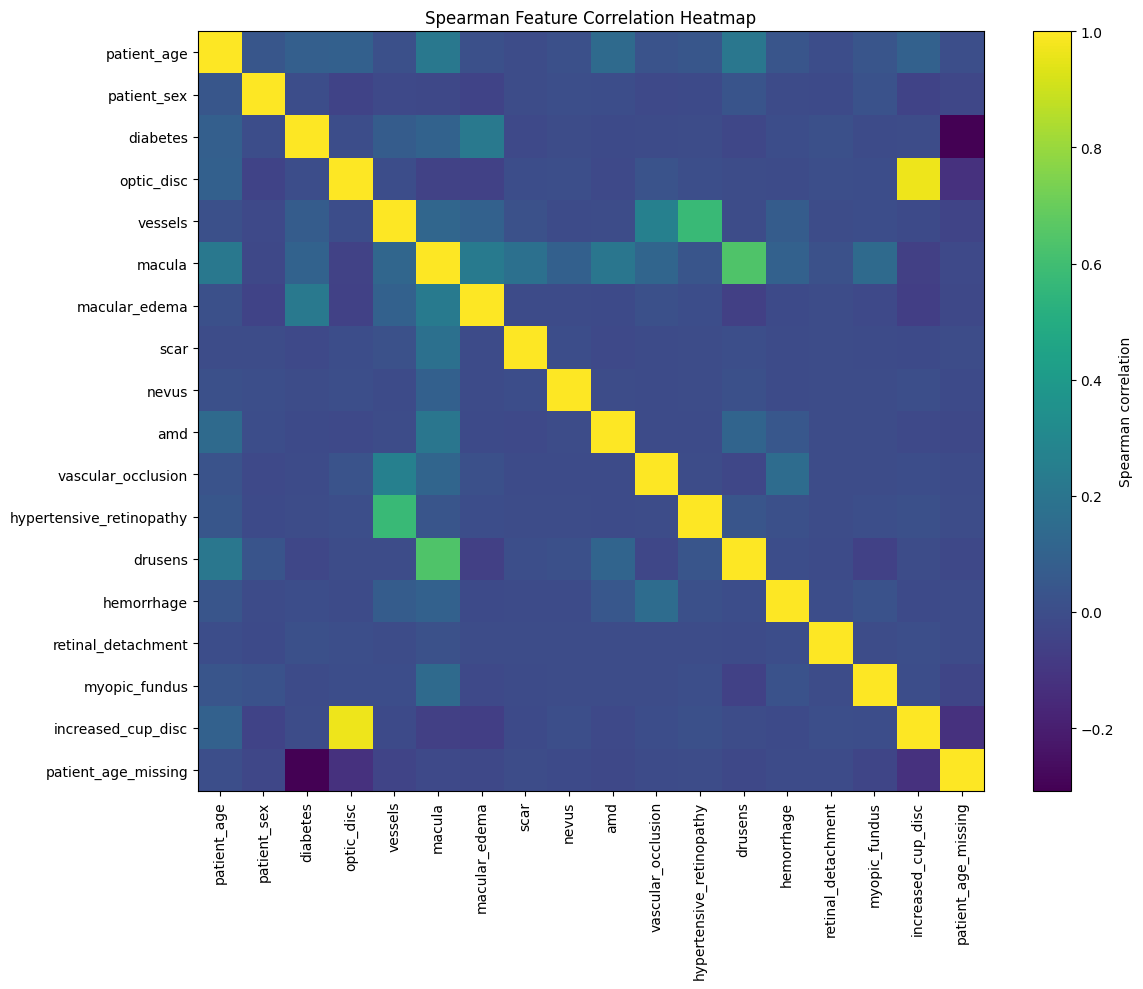

In [98]:
feature_correlation_matrix = X_train.corr(method="spearman")

plt.figure(figsize=(12, 10))
plt.imshow(feature_correlation_matrix, aspect="auto")
plt.colorbar(label="Spearman correlation")
plt.xticks(
    range(len(processed_feature_columns)),
    processed_feature_columns,
    rotation=90
)
plt.yticks(
    range(len(processed_feature_columns)),
    processed_feature_columns
)
plt.title("Spearman Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(FEATURE_CORRELATION_HEATMAP_PATH, dpi=300, bbox_inches="tight")
plt.show()

**Highly Correlated Feature Pairs**

In [111]:
CORRELATION_THRESHOLD = 0.80

correlation_abs = feature_correlation_matrix.abs()

upper_triangle_mask = np.triu(
    np.ones(correlation_abs.shape),
    k=1
).astype(bool)

high_correlation_pairs = (
    correlation_abs
    .where(upper_triangle_mask)
    .stack()
    .reset_index()
)

high_correlation_pairs.columns = [
    "feature_1",
    "feature_2",
    "spearman_abs_correlation"
]

high_correlation_pairs = (
    high_correlation_pairs[
        high_correlation_pairs["spearman_abs_correlation"] >= CORRELATION_THRESHOLD
    ]
    .sort_values("spearman_abs_correlation", ascending=False)
    .reset_index(drop=True)
)

display(high_correlation_pairs)

,feature_1,feature_2,spearman_abs_correlation
0,optic_disc,increased_cup_disc,0.964776


**Statistical Feature Selection Scores**

In [112]:
from sklearn.feature_selection import mutual_info_classif, chi2, f_classif
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import spearmanr

mi_scores = mutual_info_classif(
    X_train,
    y_train,
    random_state=SEED
)

anova_f_scores, anova_p_values = f_classif(
    X_train,
    y_train
)

chi2_scaler = MinMaxScaler()
X_train_chi2 = chi2_scaler.fit_transform(X_train)

chi2_scores, chi2_p_values = chi2(
    X_train_chi2,
    y_train
)

spearman_target_scores = []

for col in processed_feature_columns:
    corr_value, _ = spearmanr(X_train[col], y_train)

    if pd.isna(corr_value):
        corr_value = 0

    spearman_target_scores.append(abs(corr_value))

statistical_feature_scores = pd.DataFrame({
    "feature": processed_feature_columns,
    "mutual_information": mi_scores,
    "anova_f": anova_f_scores,
    "anova_p_value": anova_p_values,
    "chi2": chi2_scores,
    "chi2_p_value": chi2_p_values,
    "spearman_target_abs": spearman_target_scores
})

display(
    statistical_feature_scores
    .sort_values("mutual_information", ascending=False)
    .reset_index(drop=True)
)

,feature,mutual_information,anova_f,anova_p_value,chi2,chi2_p_value,spearman_target_abs
0,macular_edema,0.063095,1792.756380,0.000000e+00,4510.634398,0.000000e+00,0.545664
1,macula,0.053623,430.451122,0.000000e+00,1085.555779,1.023244e-233,0.335846
2,diabetes,0.042501,425.672786,0.000000e+00,1265.842267,8.469925e-273,0.339205
3,vessels,0.015341,125.240205,4.418097e-105,459.298893,4.240969e-98,0.160416
4,patient_age,0.009336,20.425966,8.566504e-17,3.668130,4.527783e-01,0.025819
5,optic_disc,0.006783,20.121875,1.545179e-16,63.688700,4.859989e-13,0.075943
6,patient_sex,0.006086,24.972351,1.247467e-20,37.479808,1.434525e-07,0.085496
7,drusens,0.005938,30.723564,1.700878e-25,100.994141,6.042037e-21,0.095634
8,increased_cup_disc,0.004179,22.094148,3.360028e-18,70.321170,1.941723e-14,0.080312
9,retinal_detachment,0.002510,0.106078,9.804361e-01,0.424267,9.804423e-01,0.005709


**ReliefF Feature Selection Scores**

In [113]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler

RELIEFF_SAMPLE_SIZE = min(3000, len(X_train))
RELIEFF_K = 10

relief_sample = X_train.sample(
    n=RELIEFF_SAMPLE_SIZE,
    random_state=SEED
)

relief_targets = y_train.loc[relief_sample.index]

relief_scaler = MinMaxScaler()
relief_X = relief_scaler.fit_transform(relief_sample)
relief_y = relief_targets.to_numpy()

classes, class_counts = np.unique(relief_y, return_counts=True)

class_priors = {
    class_label: class_count / len(relief_y)
    for class_label, class_count in zip(classes, class_counts)
}

class_neighbor_data = {}

for class_label in classes:
    class_indices = np.where(relief_y == class_label)[0]
    class_X = relief_X[class_indices]

    hit_k = min(RELIEFF_K + 1, len(class_indices))
    miss_k = min(RELIEFF_K, len(class_indices))

    hit_model = NearestNeighbors(
        n_neighbors=hit_k,
        metric="manhattan"
    ).fit(class_X)

    miss_model = NearestNeighbors(
        n_neighbors=miss_k,
        metric="manhattan"
    ).fit(class_X)

    class_neighbor_data[class_label] = {
        "indices": class_indices,
        "X": class_X,
        "hit_model": hit_model,
        "miss_model": miss_model
    }

relief_scores = np.zeros(relief_X.shape[1])

for class_label in classes:
    class_data = class_neighbor_data[class_label]
    class_indices = class_data["indices"]
    class_X = class_data["X"]

    hit_neighbors = class_data["hit_model"].kneighbors(
        class_X,
        return_distance=False
    )

    hit_neighbors = hit_neighbors[:, 1:]

    for local_i, sample_index in enumerate(class_indices):
        current_x = relief_X[sample_index]

        nearest_hits = class_X[hit_neighbors[local_i]]
        relief_scores -= np.abs(current_x - nearest_hits).mean(axis=0) / RELIEFF_SAMPLE_SIZE

        for other_class in classes:
            if other_class == class_label:
                continue

            other_data = class_neighbor_data[other_class]
            other_X = other_data["X"]

            miss_neighbors = other_data["miss_model"].kneighbors(
                current_x.reshape(1, -1),
                return_distance=False
            )[0]

            nearest_misses = other_X[miss_neighbors]

            miss_weight = class_priors[other_class] / (1 - class_priors[class_label])

            relief_scores += (
                miss_weight *
                np.abs(current_x - nearest_misses).mean(axis=0) /
                RELIEFF_SAMPLE_SIZE
            )

relief_feature_scores = pd.DataFrame({
    "feature": processed_feature_columns,
    "relief_f": relief_scores
})

display(
    relief_feature_scores
    .sort_values("relief_f", ascending=False)
    .reset_index(drop=True)
)

,feature,relief_f
0,macula,0.538377
1,diabetes,0.289464
2,patient_sex,0.176359
3,patient_age_missing,0.164856
4,drusens,0.141239
5,optic_disc,0.108615
6,increased_cup_disc,0.105679
7,patient_age,0.077306
8,macular_edema,0.073328
9,vessels,0.028048


**Tree-Based Feature Importance**

In [114]:
from sklearn.ensemble import RandomForestClassifier

rf_feature_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)

rf_feature_model.fit(X_train, y_train)

tree_feature_scores = pd.DataFrame({
    "feature": processed_feature_columns,
    "random_forest_importance": rf_feature_model.feature_importances_
})

display(
    tree_feature_scores
    .sort_values("random_forest_importance", ascending=False)
    .reset_index(drop=True)
)

,feature,random_forest_importance
0,macula,0.243828
1,macular_edema,0.183648
2,patient_age,0.165458
3,diabetes,0.155306
4,vessels,0.068687
5,drusens,0.049702
6,patient_sex,0.034475
7,patient_age_missing,0.030944
8,optic_disc,0.020632
9,increased_cup_disc,0.017705


**Permutation Feature Importance**

In [115]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import f1_score, make_scorer

permutation_result = permutation_importance(
    rf_feature_model,
    X_val,
    y_val,
    scoring=make_scorer(f1_score, average="macro"),
    n_repeats=10,
    random_state=SEED,
    n_jobs=-1
)

permutation_feature_scores = pd.DataFrame({
    "feature": processed_feature_columns,
    "permutation_importance": permutation_result.importances_mean,
    "permutation_importance_std": permutation_result.importances_std
})

display(
    permutation_feature_scores
    .sort_values("permutation_importance", ascending=False)
    .reset_index(drop=True)
)

,feature,permutation_importance,permutation_importance_std
0,macula,0.125348,0.019024
1,macular_edema,0.111258,0.016621
2,drusens,0.068253,0.015669
3,diabetes,0.059922,0.009799
4,patient_age,0.034615,0.015070
5,vessels,0.007497,0.004668
6,scar,0.003845,0.002909
7,amd,0.003358,0.001874
8,myopic_fundus,0.003033,0.000379
9,patient_age_missing,0.001536,0.006113


**SHAP Feature Importance**

In [116]:
import shap

SHAP_SAMPLE_SIZE = min(1000, len(X_train))

shap_X = X_train.sample(
    n=SHAP_SAMPLE_SIZE,
    random_state=SEED
)

shap_explainer = shap.TreeExplainer(rf_feature_model)
shap_values = shap_explainer.shap_values(shap_X)

if isinstance(shap_values, list):
    shap_importance_values = np.mean(
        [
            np.abs(class_shap_values).mean(axis=0)
            for class_shap_values in shap_values
        ],
        axis=0
    )
else:
    shap_values_array = np.array(shap_values)

    if shap_values_array.ndim == 3:
        shap_importance_values = np.abs(shap_values_array).mean(axis=(0, 2))
    else:
        shap_importance_values = np.abs(shap_values_array).mean(axis=0)

shap_feature_scores = pd.DataFrame({
    "feature": processed_feature_columns,
    "shap_importance": shap_importance_values
})

display(
    shap_feature_scores
    .sort_values("shap_importance", ascending=False)
    .reset_index(drop=True)
)

,feature,shap_importance
0,macula,0.090436
1,diabetes,0.058214
2,macular_edema,0.036462
3,patient_age,0.019194
4,drusens,0.018564
5,vessels,0.013003
6,patient_sex,0.009640
7,patient_age_missing,0.008411
8,increased_cup_disc,0.007491
9,optic_disc,0.007272


**Combined Feature Selection Ranking**

In [117]:
feature_selection_scores = (
    statistical_feature_scores
    .merge(relief_feature_scores, on="feature", how="left")
    .merge(tree_feature_scores, on="feature", how="left")
    .merge(permutation_feature_scores, on="feature", how="left")
    .merge(shap_feature_scores, on="feature", how="left")
)

ranking_score_columns = [
    "mutual_information",
    "anova_f",
    "chi2",
    "spearman_target_abs",
    "relief_f",
    "random_forest_importance",
    "permutation_importance",
    "shap_importance"
]

for col in ranking_score_columns:
    feature_selection_scores[f"{col}_rank"] = (
        feature_selection_scores[col]
        .rank(ascending=False, method="average")
    )

rank_columns = [
    f"{col}_rank"
    for col in ranking_score_columns
]

feature_selection_scores["mean_rank"] = (
    feature_selection_scores[rank_columns]
    .mean(axis=1)
)

feature_selection_scores = (
    feature_selection_scores
    .sort_values("mean_rank")
    .reset_index(drop=True)
)

display(feature_selection_scores)

,feature,mutual_information,anova_f,anova_p_value,chi2,chi2_p_value,spearman_target_abs,relief_f,random_forest_importance,permutation_importance,...,shap_importance,mutual_information_rank,anova_f_rank,chi2_rank,spearman_target_abs_rank,relief_f_rank,random_forest_importance_rank,permutation_importance_rank,shap_importance_rank,mean_rank
0,macula,0.053623,430.451122,0.000000e+00,1085.555779,1.023244e-233,0.335846,0.538377,0.243828,0.125348,...,0.090436,2.0,2.0,3.0,3.0,1.0,1.0,1.0,1.0,1.7500
1,macular_edema,0.063095,1792.756380,0.000000e+00,4510.634398,0.000000e+00,0.545664,0.073328,0.183648,0.111258,...,0.036462,1.0,1.0,1.0,1.0,9.0,2.0,2.0,3.0,2.5000
2,diabetes,0.042501,425.672786,0.000000e+00,1265.842267,8.469925e-273,0.339205,0.289464,0.155306,0.059922,...,0.058214,3.0,3.0,2.0,2.0,2.0,4.0,4.0,2.0,2.7500
3,drusens,0.005938,30.723564,1.700878e-25,100.994141,6.042037e-21,0.095634,0.141239,0.049702,0.068253,...,0.018564,8.0,5.0,5.0,5.0,5.0,6.0,3.0,5.0,5.2500
4,vessels,0.015341,125.240205,4.418097e-105,459.298893,4.240969e-98,0.160416,0.028048,0.068687,0.007497,...,0.013003,4.0,4.0,4.0,4.0,10.0,5.0,6.0,6.0,5.3750
5,patient_age,0.009336,20.425966,8.566504e-17,3.668130,4.527783e-01,0.025819,0.077306,0.165458,0.034615,...,0.019194,5.0,8.0,15.0,12.0,8.0,3.0,5.0,4.0,7.5000
6,patient_sex,0.006086,24.972351,1.247467e-20,37.479808,1.434525e-07,0.085496,0.176359,0.034475,-0.010297,...,0.009640,7.0,6.0,8.0,6.0,3.0,7.0,18.0,7.0,7.7500
7,optic_disc,0.006783,20.121875,1.545179e-16,63.688700,4.859989e-13,0.075943,0.108615,0.020632,-0.002537,...,0.007272,6.0,9.0,7.0,8.0,6.0,9.0,16.0,10.0,8.8750
8,increased_cup_disc,0.004179,22.094148,3.360028e-18,70.321170,1.941723e-14,0.080312,0.105679,0.017705,-0.002839,...,0.007491,9.0,7.0,6.0,7.0,7.0,10.0,17.0,9.0,9.0000
9,patient_age_missing,0.002353,1.590533,1.737576e-01,4.237880,3.747685e-01,0.008991,0.164856,0.030944,0.001536,...,0.008411,11.0,13.0,13.0,16.0,4.0,8.0,10.0,8.0,10.3750


**Select Final Tabular Features**

In [118]:
SELECTED_FEATURE_COUNT = 10
CORRELATION_FILTER_THRESHOLD = 0.90

selected_feature_columns = []

for feature in feature_selection_scores["feature"]:
    keep_feature = True

    for selected_feature in selected_feature_columns:
        correlation_value = abs(
            feature_correlation_matrix.loc[feature, selected_feature]
        )

        if correlation_value >= CORRELATION_FILTER_THRESHOLD:
            keep_feature = False
            break

    if keep_feature:
        selected_feature_columns.append(feature)

    if len(selected_feature_columns) == SELECTED_FEATURE_COUNT:
        break

print("Selected feature columns:")
for col in selected_feature_columns:
    print("-", col)

Selected feature columns:
- macula
- macular_edema
- diabetes
- drusens
- vessels
- patient_age
- patient_sex
- optic_disc
- patient_age_missing
- hypertensive_retinopathy


**Feature Selection Ranking Plot**

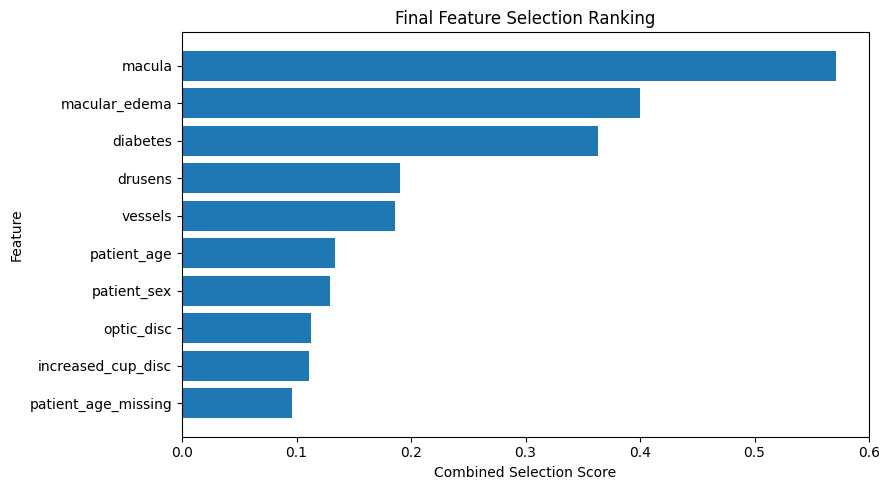

In [119]:
top_feature_scores = feature_selection_scores.head(SELECTED_FEATURE_COUNT).copy()
top_feature_scores["combined_selection_score"] = 1 / top_feature_scores["mean_rank"]

plt.figure(figsize=(9, 5))
plt.barh(
    top_feature_scores["feature"][::-1],
    top_feature_scores["combined_selection_score"][::-1]
)
plt.title("Final Feature Selection Ranking")
plt.xlabel("Combined Selection Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(FEATURE_SELECTION_RANKING_FIGURE_PATH, dpi=300, bbox_inches="tight")
plt.show()

**Save Selected Tabular Artifacts**

In [120]:
selected_tabular_columns = list(
    dict.fromkeys(
        ["processed_image_path", "split", TARGET_COL]
        + selected_feature_columns
        + cohort_columns
    )
)

selected_tabular_df = df[selected_tabular_columns].copy()

selected_tabular_df.to_csv(SELECTED_TABULAR_PATH, index=False)
feature_selection_scores.to_csv(FEATURE_SELECTION_SCORES_PATH, index=False)

preprocessing_metadata = {
    "target": {
        "source_target_column": SOURCE_TARGET_COL,
        "target_column": TARGET_COL,
        "task": "5-class diabetic retinopathy severity classification"
    },
    "tabular_preprocessing": {
        "age_imputation": {
            "column": "patient_age",
            "strategy": "train_median",
            "value": float(patient_age_median)
        },
        "age_scaling": {
            "column": "patient_age",
            "strategy": "StandardScaler",
            "mean": float(age_scaler.mean_[0]),
            "scale": float(age_scaler.scale_[0])
        },
        "categorical_encoder_mappings": categorical_encoder_mappings
    },
    "feature_columns": {
        "candidate_features": candidate_feature_columns,
        "processed_features": processed_feature_columns,
        "selected_features": selected_feature_columns,
        "cohort_columns": cohort_columns,
        "non_feature_columns": [
            "processed_image_path",
            "split",
            TARGET_COL
        ]
    },
    "feature_selection": {
        "selected_feature_count": SELECTED_FEATURE_COUNT,
        "ranking_metric": "mean_rank",
        "methods": [
            "mutual_information",
            "anova_f",
            "chi2",
            "spearman_target_abs",
            "relief_f",
            "random_forest_importance",
            "extra_trees_importance",
            "permutation_importance",
            "shap_importance"
        ]
    }
}

with open(PREPROCESSING_METADATA_PATH, "w") as f:
    json.dump(preprocessing_metadata, f, indent=2)